# From Footprints to Building Stock Insights

* **Authors:** Markus Münzinger & Martin Behnisch (IOER)
* **Badges:** ![Interactive](https://img.shields.io/badge/Type-Interactive_Code-blue?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter) ![Data](https://img.shields.io/badge/ioerDATA-doi%3A10.71830%2F9CBBWV-0970B9?style=flat-square)

## Background
This notebook presents the core analysis from the Jupyter Book *"From Footprints to Building Stock Insights"* – a spatial decision-support pipeline for sustainable transformation. The work transforms **57 million building footprints** across Germany into comparable building stock characteristics for evidence-based decision-making.

## The Problem
Germany has ~57 million buildings and structures, but this data is difficult to use directly:
- Too many footprints to analyse individually
- Complex 3D formats requiring specialised software
- Large file sizes (~5 GB for the full dataset)
- No direct comparability across municipalities

## The Solution Pipeline
The original book builds a pipeline that:
1. Assigns each footprint to its municipality (spatial join)
2. Aggregates data to administrative units
3. Combines with the RegioStaR spatial typology
4. Analyses the distribution of building stock
5. Visualises results for decision-makers

## Dataset Used
- **Name:** 3D Building Metrics Germany 2024
- **DOI:** [10.71830/9CBBWV](https://doi.org/10.71830/9CBBWV)
- **Source:** Official 3D building models (LoD2)
- **Coverage:** Germany (16 federal states), year 2024
- **Format:** GeoParquet (~5 GB total)
- **License:** CC BY 4.0

## Book Structure (Original Chapters)
| Part | Chapters | Content |
|------|----------|---------|
| I | 1–3 | The dataset and the research question |
| II | 4–5 | Analytical highlights (Lorenz curves, Gini coefficients, maps) |
| III | 6–7 | From footprints to administrative data (full pipeline) |
| IV | 8 | Why the full pipeline is documented |
| V | 9 | Accessing the full dataset |
| VI | 10 | Reuse and adaptation |

## Key Finding (Preview)
Metropolitan urban regions show the highest concentration of building volume (Gini = 0.669; top 10% of VWGs hold 60.3% of volume), compared to rural regions (Gini ≈ 0.42–0.44; top 10% ≈ 31–32%).

## Applications
- **Circular Economy:** Identify regions with high building volume for material recycling potential
- **Energy Transition:** Prioritise areas for energy-efficient retrofits
- **Urban Resilience:** Understand building stock distribution for vulnerability and densification planning

---

*This notebook focuses on the main analysis and results. For the full pipeline, data processing details, and reproduction steps, please refer to the complete Jupyter Book.*

## Chapter 5: Analysing Building Footprint Distributions

**Goal:** Understand how building volume is distributed across VWGs within each RegioStaR4 class.

In this chapter, we:
- Compute Lorenz curves for each RegioStaR4 class
- Calculate Gini coefficients
- Identify top 10% VWGs
- Visualise results on maps

> **Note:** This chapter uses the analytical dataset from Chapter 4 – no need for the full footprint dataset.

### Setup

First, let's load the analytical dataset we created in Chapter 4.

In [15]:
# ============================================================
# Setup and load data
# ============================================================
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

# Define root directory (two levels up from book/chapters/)
ROOT = Path.cwd().parent.parent

# Load the analytical dataset from Chapter 4 (CSV)
DATA_PATH = ROOT / "data" / "processed" / "vwg_building_stats_regiostar4.csv"
vwg_agg = pd.read_csv(
    DATA_PATH,
    dtype={
        'ars_vwg': 'object',
        'n_municipalities': 'int',
        'n_buildings': 'int',
        'total_volume_m3': 'float',
        'total_footprint_m2': 'float',
        'population': 'int',
        'vwg_name': 'object',
        'regiostar4_code': 'object',
        'regiostar4_name': 'object'
    }
)

# Path to VWG geometries
VG25_GPKG_PATH = ROOT / "data" / "raw" / "VG25" / "Daten" / "DE_VG25.gpkg"

print(f"Loaded {len(vwg_agg):,} VWGs")
print(f"Columns: {list(vwg_agg.columns)}")
print(f"VG25 file exists: {VG25_GPKG_PATH.exists()}")

Loaded 4,559 VWGs
Columns: ['ars_vwg', 'n_municipalities', 'n_buildings', 'total_volume_m3', 'total_footprint_m2', 'population', 'vwg_name', 'regiostar4_code', 'regiostar4_name']
VG25 file exists: True


### What is a Lorenz Curve?

A **Lorenz curve** shows how a resource (here: building volume) is distributed across a population (here: VWGs).

- **X-axis:** Cumulative share of VWGs (sorted by volume, smallest to largest)
- **Y-axis:** Cumulative share of building volume
- **Diagonal line:** Perfect equality (every VWG has the same volume)

The further the curve bows below the diagonal, the more **concentrated** the volume is among a few VWGs.

### What is the Gini Coefficient?

A number between 0 and 1:
- **0** = perfect equality (all VWGs have the same volume)
- **1** = perfect inequality (one VWG has everything)

## Lorenz Curve Function

Let's define a function to compute Lorenz curves and Gini coefficients.

In [16]:
# ============================================================
# Lorenz curve function
# ============================================================
def lorenz_curve(values):
    """
    Compute the Lorenz curve and Gini coefficient.
    
    Parameters:
        values: array-like of positive numbers
    
    Returns:
        cum_share_n: cumulative share of entities (x-axis)
        cum_share_value: cumulative share of values (y-axis)
        gini: Gini coefficient (0 = equal, 1 = concentrated)
    """
    # Sort values ascending
    values = np.sort(np.asarray(values, dtype=float))
    values = values[values >= 0]
    n = len(values)
    
    # Handle edge case
    if n == 0 or values.sum() == 0:
        return np.array([0, 1]), np.array([0, 1]), np.nan
    
    # Compute cumulative shares
    cum_values = np.cumsum(values)
    cum_share_value = np.insert(cum_values / cum_values[-1], 0, 0)
    cum_share_n = np.insert(np.arange(1, n + 1) / n, 0, 0)
    
    # Gini coefficient
    gini = 1 - 2 * np.trapezoid(cum_share_value, cum_share_n)
    
    return cum_share_n, cum_share_value, gini

### Plot Lorenz Curves

Let's plot the Lorenz curves for each RegioStaR4 class.

**How to read this chart:**

- **X-axis:** Cumulative share of VWGs (sorted by volume, smallest to largest)
- **Y-axis:** Cumulative share of building volume
- **Diagonal line:** Perfect equality (every VWG has the same volume)

**What to look for:**

- **Closer to the diagonal** – More equal distribution
- **Further from the diagonal** – More concentrated distribution (a few VWGs hold most of the volume)

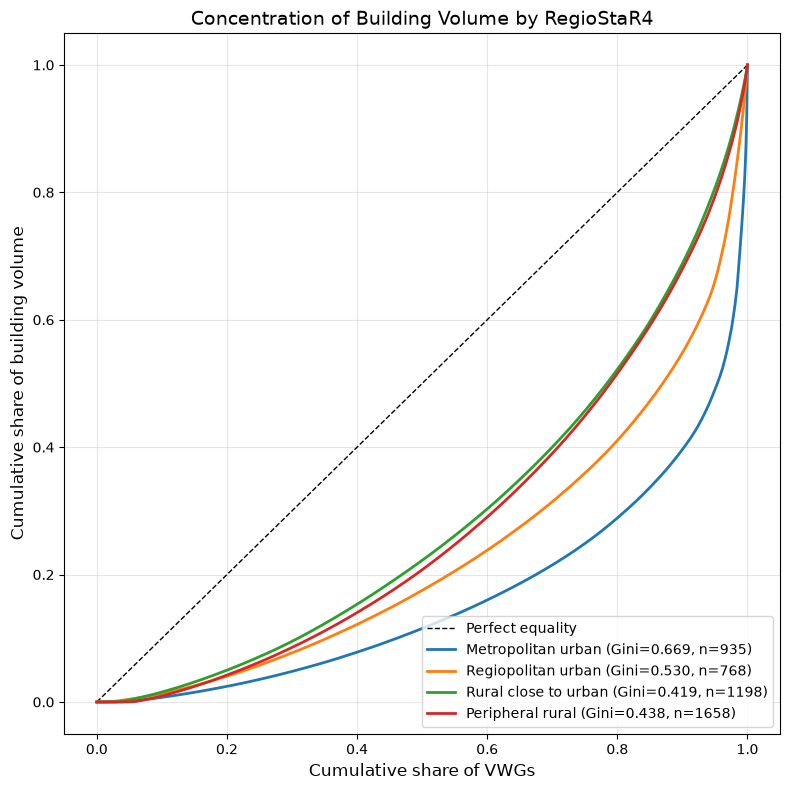

In [17]:
# ============================================================
# Plot Lorenz curves by RegioStaR4
# ============================================================
# Labels for RegioStaR4 classes
regiostar4_labels = {
    '11': 'Metropolitan urban',
    '12': 'Regiopolitan urban',
    '21': 'Rural close to urban',
    '22': 'Peripheral rural'
}

# Create plot
fig, ax = plt.subplots(figsize=(8, 8))

# Perfect equality line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect equality', linewidth=1)

# Plot each class
for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code]
    x, y, gini = lorenz_curve(group['total_volume_m3'])
    label = f"{regiostar4_labels[code]} (Gini={gini:.3f}, n={len(group)})"
    ax.plot(x, y, label=label, linewidth=2)

ax.set_xlabel('Cumulative share of VWGs', fontsize=12)
ax.set_ylabel('Cumulative share of building volume', fontsize=12)
ax.set_title('Concentration of Building Volume by RegioStaR4', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### What the Curves Show

- **Metropolitan urban (red)** – Curve bows furthest from the diagonal → highest concentration
- **Regiopolitan urban (blue)** – Moderate bow → noticeable concentration
- **Rural close to urban (green)** – Closest to diagonal → lowest concentration, but still moderate
- **Peripheral rural (purple)** – Similar to green → moderate concentration

All classes show **moderate to high concentration** – none are close to perfect equality.

---

### Concentration Metrics

To quantify these patterns, we compute:

- **Gini coefficient** – 0 = perfect equality, 1 = perfect concentration
- **Top 10% share** – What percentage of total building volume is held by the largest 10% of VWGs in each class
- **Top 20% share** – What percentage of total building volume is held by the largest 20% of VWGs in each class

**Why these metrics matter:**

- **Gini** – Summarises overall inequality in one number
- **Top 10%/20% shares** – Show how much volume is controlled by the largest VWGs – useful for identifying dominant centers

In [18]:
# ============================================================
# Concentration metrics by RegioStaR4
# ============================================================
print(f"{'Class':<25} {'VWGs':>6} {'Gini':>8} {'Top10% VWGs':>12} {'Top20% VWGs':>12}")
print("-" * 65)

for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code]
    
    # Compute Gini
    x, y, gini = lorenz_curve(group['total_volume_m3'])
    
    # Sort volumes descending
    sorted_vals = np.sort(group['total_volume_m3'].values)[::-1]
    total_vol = sorted_vals.sum()
    
    # Top 10% share
    n_top10 = max(1, int(len(group) * 0.1))
    top10_share = sorted_vals[:n_top10].sum() / total_vol * 100
    
    # Top 20% share
    n_top20 = max(1, int(len(group) * 0.2))
    top20_share = sorted_vals[:n_top20].sum() / total_vol * 100
    
    print(f"{regiostar4_labels[code]:<25} {len(group):>6,} {gini:>8.3f} {top10_share:>11.1f}% {top20_share:>11.1f}%")

Class                       VWGs     Gini  Top10% VWGs  Top20% VWGs
-----------------------------------------------------------------
Metropolitan urban           935    0.669        60.3%        71.1%
Regiopolitan urban           768    0.530        45.0%        58.9%
Rural close to urban       1,198    0.419        31.0%        47.7%
Peripheral rural           1,658    0.438        31.9%        48.4%


#### Interpretation

- **Metropolitan urban** (Gini = 0.669): Highest concentration. Top 10% of VWGs hold 60% of building volume.
- **Regiopolitan urban** (Gini = 0.530): Moderate concentration.
- **Rural close to urban** (Gini = 0.419): More equal distribution.
- **Peripheral rural** (Gini = 0.438): Similar to rural close to urban.

**Key insight:** Building volume is most concentrated in metropolitan areas – a few large cities dominate.

---

### Why Split by RegioStaR4?

Before looking at the maps, let's examine the **actual building volumes** per class.

**Why this matters:**

Without splitting by RegioStaR4, the analysis would be **dominated by metropolitan urban regions** – they have the highest volume per VWG and the highest concentration (Gini = 0.669).

By splitting into classes, we can:

- Compare **structurally similar** municipalities
- Identify patterns **within** each region type
- Avoid the analysis being **skewed** by a few large cities


In [19]:
# ============================================================
# Building volume by RegioStaR4 class
# ============================================================
volume_by_class = vwg_agg.groupby(['regiostar4_code', 'regiostar4_name']).agg(
    n_vwgs=('ars_vwg', 'count'),
    total_volume_m3=('total_volume_m3', 'sum')
).reset_index()

# Calculate share of total volume
total_volume_all = volume_by_class['total_volume_m3'].sum()
volume_by_class['share_of_total'] = volume_by_class['total_volume_m3'] / total_volume_all * 100

# Calculate volume per VWG
volume_by_class['volume_per_vwg'] = volume_by_class['total_volume_m3'] / volume_by_class['n_vwgs']

# Format for display
display_df = volume_by_class.copy()
display_df['total_volume_m3'] = display_df['total_volume_m3'].map(lambda x: f"{x/1e9:.1f} billion")
display_df['share_of_total'] = display_df['share_of_total'].map(lambda x: f"{x:.1f}%")
display_df['volume_per_vwg'] = display_df['volume_per_vwg'].map(lambda x: f"{x/1e6:.1f} million m³")

display_df.columns = ['Code', 'Class', 'VWGs', 'Total Volume', 'Share of Total', 'Volume per VWG']
print("Building volume by RegioStaR4 class:")
display(display_df)

Building volume by RegioStaR4 class:


,Code,Class,VWGs,Total Volume,Share of Total,Volume per VWG
0,11,Metropolitan urban region,935,16.4 billion,34.9%,17.6 million m³
1,12,Regiopolitan urban region,768,9.3 billion,19.9%,12.1 million m³
2,21,Rural region close to an urban region,1198,10.3 billion,21.9%,8.6 million m³
3,22,Peripheral rural region,1658,10.9 billion,23.3%,6.6 million m³


#### What the Table Shows

| RegioStaR4 | VWGs | Total Volume | Share | Volume per VWG |
|------------|------|--------------|-------|----------------|
| Metropolitan urban | 935 | 16.4 billion m³ | 34.9% | 17.6 million m³ |
| Regiopolitan urban | 768 | 9.3 billion m³ | 19.9% | 12.1 million m³ |
| Rural close to urban | 1,198 | 10.3 billion m³ | 21.9% | 8.6 million m³ |
| Peripheral rural | 1,658 | 10.9 billion m³ | 23.3% | 6.6 million m³ |

**Key observations:**

- **Metropolitan urban** – Highest volume per VWG (17.6 million m³) – large cities dominate
- **Peripheral rural** – Most VWGs (1,658) but lowest volume per VWG (6.6 million m³)
- **Rural areas combined** hold about **45%** of total building volume – a substantial share

This confirms why splitting by RegioStaR4 is useful – without it, the analysis would be dominated by metropolitan regions.


--- 

### Identify Top 10% VWGs

Let's identify which VWGs belong to the top 10% in each class.

This step prepares the data for the **maps** later in this chapter – we'll highlight these top VWGs visually to see where the largest building volumes are concentrated across Germany.


In [20]:
# ============================================================
# Identify top 10% VWGs per RegioStaR4 class
# ============================================================
top10_vwgs = []

for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code].copy()
    group = group.sort_values('total_volume_m3', ascending=False)
    n_top10 = max(1, int(len(group) * 0.1))
    group['top10'] = False
    group.iloc[:n_top10, group.columns.get_loc('top10')] = True
    top10_vwgs.append(group[['ars_vwg', 'regiostar4_code', 'regiostar4_name', 
                              'total_volume_m3', 'top10']])

top10_df = pd.concat(top10_vwgs, ignore_index=True)
print(f"Identified top 10% VWGs: {top10_df['top10'].sum():,}")
top10_df[top10_df['top10'] == True].head(10)

Identified top 10% VWGs: 453


,ars_vwg,regiostar4_code,regiostar4_name,total_volume_m3,top10
0,110000000,11,Metropolitan urban region,1.263238e+09,True
1,020000000,11,Metropolitan urban region,7.320077e+08,True
2,091620000,11,Metropolitan urban region,4.972838e+08,True
3,053150000,11,Metropolitan urban region,4.234902e+08,True
4,064120000,11,Metropolitan urban region,3.374048e+08,True
5,040110000,11,Metropolitan urban region,2.941626e+08,True
6,051110000,11,Metropolitan urban region,2.775604e+08,True
7,147130000,11,Metropolitan urban region,2.622065e+08,True
8,032410001,11,Metropolitan urban region,2.518303e+08,True
9,081110000,11,Metropolitan urban region,2.516939e+08,True


### Load VWG Geometries

Now let's load the VWG polygons for mapping.

So far, we've worked with aggregated data on **municipal associations (Gemeindeverbände)** – derived from individual municipalities (Gemeinden). 

For the map, we now join this data to the **actual geometries** of these associations. We load them from the VG25 GeoPackage (layer: `vg25_vwg`), which contains the official administrative boundaries provided by BKG.

In [21]:
# ============================================================
# Load VWG geometries
# ============================================================
print("Loading VWG geometries...")
vwg_geom = gpd.read_file(VG25_GPKG_PATH, layer='vg25_vwg', engine='pyogrio')
print(f"Loaded {len(vwg_geom):,} VWG polygons")

# Join top 10% data to geometries
vwg_geom_join = vwg_geom.merge(top10_df, left_on='ARS', right_on='ars_vwg', how='inner')
print(f"Joined: {len(vwg_geom_join):,} VWGs with geometry")

Loading VWG geometries...
Loaded 4,599 VWG polygons
Joined: 4,559 VWGs with geometry


### Map: Top 10% VWGs by RegioStaR4 Class

Now let's visualise the top 10% VWGs on a map.

**Why this map matters:**

The analysis by RegioStaR4 enables us to see **differentiated patterns** across Germany – patterns that would otherwise be **dominated by urban Gemeindeverbände**.

By splitting into four classes and highlighting the top 10% within each, we can see:

- **Where** the largest building volumes are concentrated within each region type
- **How** the spatial patterns differ between metropolitan, regiopolitan, and rural areas
- **Which** VWGs stand out – beyond just the big cities

**Color scheme:**

- **Red** – Metropolitan urban regions
- **Blue** – Regiopolitan urban regions
- **Green** – Rural regions close to urban areas
- **Purple** – Peripheral rural regions

**Full color** = top 10% VWGs (highlighted)  
**Faded color** = other VWGs in that class

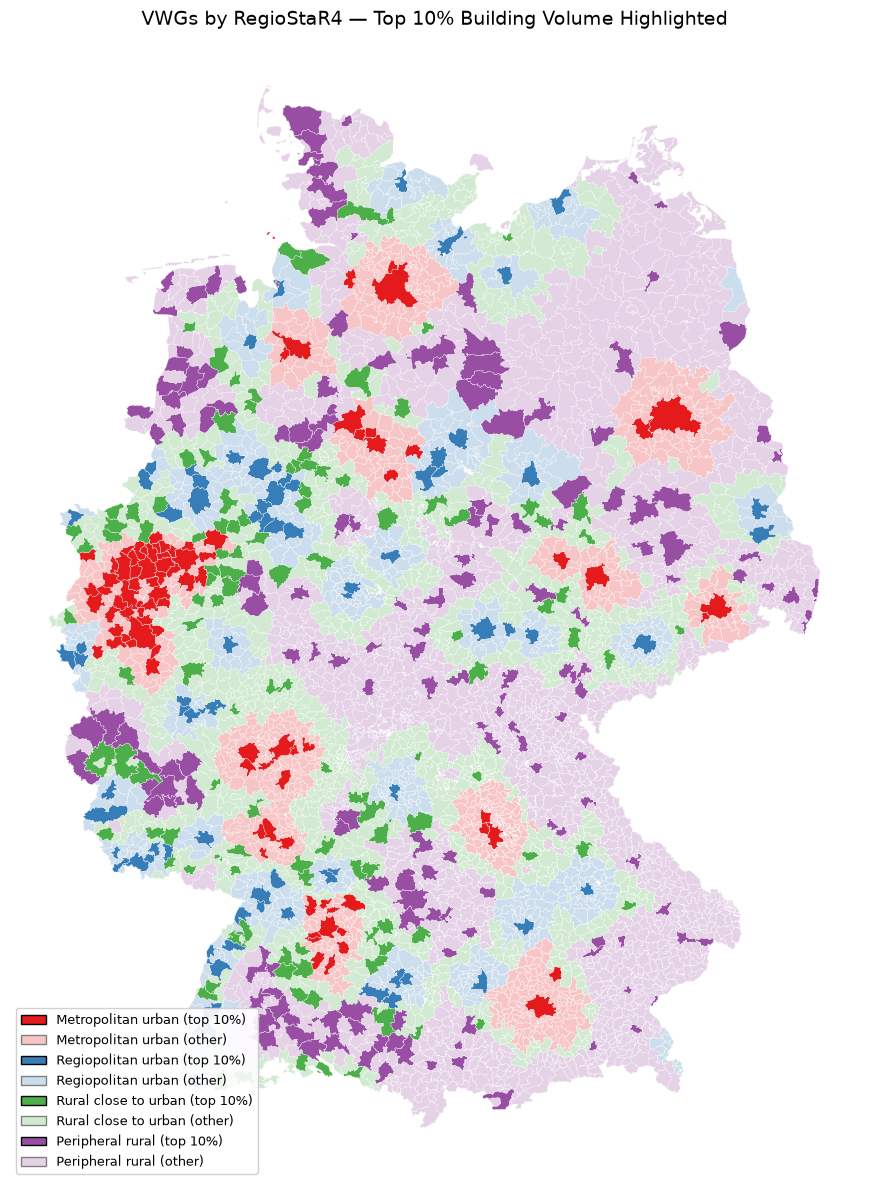

Map saved to: A:\tarox03_user4\Muenzinger\8_current_processing\ioer_hacklathon_3d_building_metrics_2024\3d-building-pareto-analysis\images\map_top10_single.png


In [22]:
# ============================================================
# Single map with all classes
# ============================================================
# Color scheme for each RegioStaR4 class
class_colors = {
    '11': '#e41a1c',  # red
    '12': '#377eb8',  # blue
    '21': '#4daf4a',  # green
    '22': '#984ea3'   # purple
}

# Create color column
def get_color(row):
    base_color = to_rgba(class_colors[row['regiostar4_code']])
    if row['top10']:
        return base_color  # full saturation
    else:
        return (base_color[0], base_color[1], base_color[2], 0.25)  # faint

vwg_geom_join['color'] = vwg_geom_join.apply(get_color, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot all VWGs
vwg_geom_join.plot(ax=ax, color=vwg_geom_join['color'], edgecolor='white', linewidth=0.2)

# Add legend
legend_elements = []
for code, color in class_colors.items():
    legend_elements.append(
        Patch(facecolor=color, edgecolor='black', label=f"{regiostar4_labels[code]} (top 10%)")
    )
    legend_elements.append(
        Patch(facecolor=to_rgba(color, alpha=0.25), edgecolor='grey', 
              label=f"{regiostar4_labels[code]} (other)")
    )

ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('VWGs by RegioStaR4 — Top 10% Building Volume Highlighted', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


# ============================================================
# Save the map for use in other chapters
# ============================================================
images_dir = ROOT / "images"
images_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(images_dir / "map_top10_single.png", dpi=300, bbox_inches='tight')
print(f"Map saved to: {images_dir / 'map_top10_single.png'}")

#### What This Means for Your Work

The maps reveal **distinct spatial patterns** of building volume concentration across Germany:

- **Metropolitan regions** – Volume is highly concentrated in a few large centers
- **Rural regions** – Volume is more evenly distributed across many VWGs

These patterns are not just descriptive – they are **actionable**. We invite you to explore, adapt, and extend the pipeline to your own research questions – whether in the circular economy, energy transition, or urban resilience.

#### Try It Yourself

Here are some ideas to get started:

1. **Use roof area** instead of building volume
2. **Change the threshold** – top 5% or top 20%
3. **Compute Gini for roof area**
4. **Compare RegioStaR2 vs RegioStaR4**

Modify the code above and see what patterns emerge!

### Summary

In this chapter, we:

- ✅ Computed Lorenz curves for each RegioStaR4 class
- ✅ Calculated Gini coefficients
- ✅ Identified top 10% VWGs
- ✅ Created 4-panel and single maps
- ✅ Explored spatial patterns

**Key takeaway:** Building volume is highly concentrated in metropolitan areas. The top 10% of VWGs in these regions hold 60% of all building volume.

---

*Continue to [Chapter 6: Spatially Joining Footprints to Administrative Boundaries](06_spatial_join.ipynb)*